In [2]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib
import json
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, f1_score, accuracy_score
)

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

# Ensure we're in project root
os.chdir(r'C:\code_projects\FinSight AI\finsight-ai')
print(f"Working directory: {os.getcwd()}")
print("All imports successful!")

c:\code_projects\FinSight AI\finsight-ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: C:\code_projects\FinSight AI\finsight-ai
All imports successful!


In [3]:
# Cell 2: Load data and recreate clean dataset (same steps as EDA notebook)
COLUMNS_TO_LOAD = ['loan_status', 'annual_inc', 'installment', 'dti', 
                   'int_rate', 'revol_bal', 'revol_util']

DATA_PATH = r'data\raw\lending_club\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv'

print("Loading dataset... (30-60 seconds)")
df_raw = pd.read_csv(DATA_PATH, usecols=COLUMNS_TO_LOAD, low_memory=False)

# Filter to completed loans only
valid_statuses = ['Fully Paid', 'Charged Off']
df = df_raw[df_raw['loan_status'].isin(valid_statuses)].copy()

# Create binary target
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Drop rows with missing values
required_cols = ['annual_inc', 'installment', 'dti', 'int_rate', 'revol_bal', 'revol_util']
df = df.dropna(subset=required_cols)

print(f"Clean dataset: {len(df):,} rows")
print(f"Default rate: {df['target'].mean()*100:.2f}%")

Loading dataset... (30-60 seconds)
Clean dataset: 1,344,080 rows
Default rate: 19.96%


In [4]:
# Cell 3: Cap outliers using IQR method
# Instead of removing outliers (loses data), we CAP them at the IQR boundaries
# This preserves all rows while limiting extreme values

def cap_outliers_iqr(series, multiplier=1.5):
    """Cap values at Q1 - 1.5*IQR and Q3 + 1.5*IQR"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    capped = series.clip(lower=lower, upper=upper)
    n_capped = ((series < lower) | (series > upper)).sum()
    return capped, n_capped, lower, upper

print("=" * 60)
print("OUTLIER CAPPING (IQR Method)")
print("=" * 60)

cols_to_cap = ['annual_inc', 'installment', 'dti', 'int_rate', 'revol_bal', 'revol_util']

for col in cols_to_cap:
    df[col], n_capped, lower, upper = cap_outliers_iqr(df[col])
    print(f"{col:15s} | Capped: {n_capped:,} rows | Range: [{lower:.2f}, {upper:.2f}]")

print(f"\nTotal rows preserved: {len(df):,} (no rows dropped)")

OUTLIER CAPPING (IQR Method)
annual_inc      | Capped: 65,786 rows | Range: [-20250.00, 156150.00]
installment     | Capped: 41,978 rows | Range: [-249.90, 1079.11]
dti             | Capped: 5,483 rows | Range: [-6.59, 42.45]
int_rate        | Capped: 24,923 rows | Range: [0.39, 25.35]
revol_bal       | Capped: 79,608 rows | Range: [-14762.50, 40473.50]
revol_util      | Capped: 72 rows | Range: [-22.55, 126.65]

Total rows preserved: 1,344,080 (no rows dropped)


In [5]:
# Cell 4: Engineer the 5 financial ratios
# These MUST match exactly what Agent 2 (LLaMA) will extract from financial documents

# 1. DSCR (Debt Service Coverage Ratio) = Income / Debt Payments
#    Higher = better (more income to cover debt)
df['dscr'] = df['annual_inc'] / (12 * df['installment'])

# 2. Leverage Ratio = DTI (debt-to-income, used directly)
#    Higher = worse (more debt relative to income)
df['leverage_ratio'] = df['dti']

# 3. Interest Coverage = Annual Income / Interest Rate (scaled)
#    Higher = better (more income to cover interest)
df['interest_coverage'] = df['annual_inc'] / (df['int_rate'] + 0.01)  # +0.01 to avoid division by zero

# 4. Current Ratio = Revolving Balance / Revolving Utilization (scaled)
#    Represents short-term liquidity
df['current_ratio'] = df['revol_bal'] / (df['revol_util'] + 0.01)  # +0.01 to avoid division by zero

# 5. Net Profit Margin = (Income - Debt Payments) / Income
#    Higher = better (more income left after obligations)
df['net_profit_margin'] = (df['annual_inc'] - (12 * df['installment'])) / (df['annual_inc'] + 0.01)

# Our 5 engineered features
FEATURE_COLS = ['dscr', 'leverage_ratio', 'interest_coverage', 'current_ratio', 'net_profit_margin']

print("=" * 60)
print("ENGINEERED FEATURES — STATISTICAL SUMMARY")
print("=" * 60)
print(df[FEATURE_COLS].describe().round(4))

print(f"\nMissing values in engineered features:")
print(df[FEATURE_COLS].isnull().sum())

ENGINEERED FEATURES — STATISTICAL SUMMARY
               dscr  leverage_ratio  interest_coverage  current_ratio  \
count  1.344080e+06    1.344080e+06       1.344080e+06   1.344080e+06   
mean   1.865110e+01    1.815270e+01       6.409485e+03   1.319777e+03   
std    1.779380e+01    8.502700e+00       4.509489e+03   5.790531e+04   
min    3.500000e-03   -1.000000e+00       1.135600e+00   0.000000e+00   
25%    9.528800e+00    1.180000e+01       3.296703e+03   1.389488e+02   
50%    1.368340e+01    1.762000e+01       5.118110e+03   2.388669e+02   
75%    2.102270e+01    2.406000e+01       8.148148e+03   4.023736e+02   
max    1.690331e+03    4.245000e+01       2.935150e+04   4.047350e+06   

       net_profit_margin  
count       1.344080e+06  
mean        9.191000e-01  
std         3.750000e-01  
min        -2.814971e+02  
25%         8.951000e-01  
50%         9.269000e-01  
75%         9.524000e-01  
max         9.994000e-01  

Missing values in engineered features:
dscr             

In [7]:
# Cell 5: Handle any infinities from division, then compute and save training medians

# Replace any inf/-inf values with NaN, then fill with column median
for col in FEATURE_COLS:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# Compute medians BEFORE filling (these are the "true" training medians)
medians = {}
for col in FEATURE_COLS:
    medians[col] = round(float(df[col].median()), 4)

print("=" * 60)
print("TRAINING MEDIANS (saved for inference-time imputation)")
print("=" * 60)
for feat, med in medians.items():
    print(f"  {feat:25s}: {med}")

# Fill any remaining NaN with medians
for col in FEATURE_COLS:
    df[col] = df[col].fillna(medians[col])

# Verify: zero nulls and zero infinities
assert df[FEATURE_COLS].isnull().sum().sum() == 0, "Still has nulls!"
assert np.isinf(df[FEATURE_COLS].values).sum() == 0, "Still has infinities!"
print(f"\nVerified: Zero nulls, zero infinities in all 5 features")

# Save medians to models/medians.json
os.makedirs('models', exist_ok=True)
with open('models/medians.json', 'w') as f:
    json.dump(medians, f, indent=2)
print(f"Saved medians to models/medians.json")

TRAINING MEDIANS (saved for inference-time imputation)
  dscr                     : 13.6834
  leverage_ratio           : 17.62
  interest_coverage        : 5118.1102
  current_ratio            : 238.8669
  net_profit_margin        : 0.9269

Verified: Zero nulls, zero infinities in all 5 features
Saved medians to models/medians.json


In [8]:
# Cell 6: Train/Test split (80/20, stratified)
X = df[FEATURE_COLS]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} rows")
print(f"Test set:     {len(X_test):,} rows")
print(f"\nTraining default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:     {y_test.mean()*100:.2f}%")
print("(Rates match — stratified split working correctly)")

# Calculate scale_pos_weight for class imbalance
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive
print(f"\nscale_pos_weight: {scale_pos_weight:.2f} (ratio of non-default to default)")

Training set: 1,075,264 rows
Test set:     268,816 rows

Training default rate: 19.96%
Test default rate:     19.96%
(Rates match — stratified split working correctly)

scale_pos_weight: 4.01 (ratio of non-default to default)


In [9]:
# Cell 7: Train XGBoost classifier
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,  # Handles class imbalance
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,                          # Use all CPU cores
    use_label_encoder=False,
)

print("Training XGBoost... (this may take 1-3 minutes)")

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50  # Print progress every 50 trees
)

print("\nTraining complete!")

Training XGBoost... (this may take 1-3 minutes)
[0]	validation_0-auc:0.65082	validation_1-auc:0.64980
[50]	validation_0-auc:0.65664	validation_1-auc:0.65440
[100]	validation_0-auc:0.65869	validation_1-auc:0.65515
[150]	validation_0-auc:0.66006	validation_1-auc:0.65525
[200]	validation_0-auc:0.66134	validation_1-auc:0.65530
[250]	validation_0-auc:0.66259	validation_1-auc:0.65535
[299]	validation_0-auc:0.66407	validation_1-auc:0.65538

Training complete!


MODEL EVALUATION RESULTS
AUC-ROC:  0.6554  (target > 0.80) ✗ FAIL
Accuracy: 0.5963
F1 Score: 0.3872

Classification Report:
                 precision    recall  f1-score   support

 Fully Paid (0)       0.87      0.59      0.70    215154
Charged Off (1)       0.28      0.64      0.39     53662

       accuracy                           0.60    268816
      macro avg       0.57      0.61      0.54    268816
   weighted avg       0.75      0.60      0.64    268816



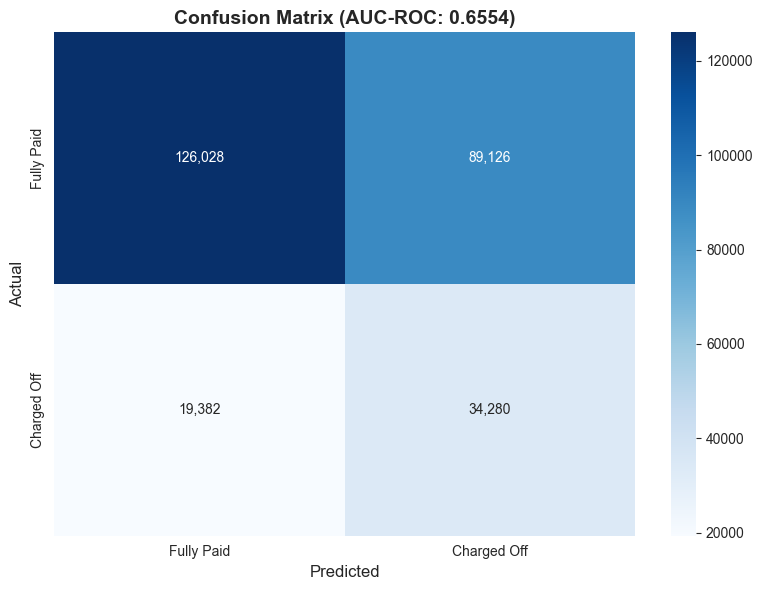

Plot saved to notebooks/confusion_matrix_xgboost.png


In [10]:
# Cell 8: Model evaluation
# Predict probabilities (0.0 to 1.0)
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Core metrics
auc_roc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"AUC-ROC:  {auc_roc:.4f}  (target > 0.80) {'✓ PASS' if auc_roc > 0.80 else '✗ FAIL'}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fully Paid (0)', 'Charged Off (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Fully Paid', 'Charged Off'],
            yticklabels=['Fully Paid', 'Charged Off'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix (AUC-ROC: {auc_roc:.4f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/confusion_matrix_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to notebooks/confusion_matrix_xgboost.png")

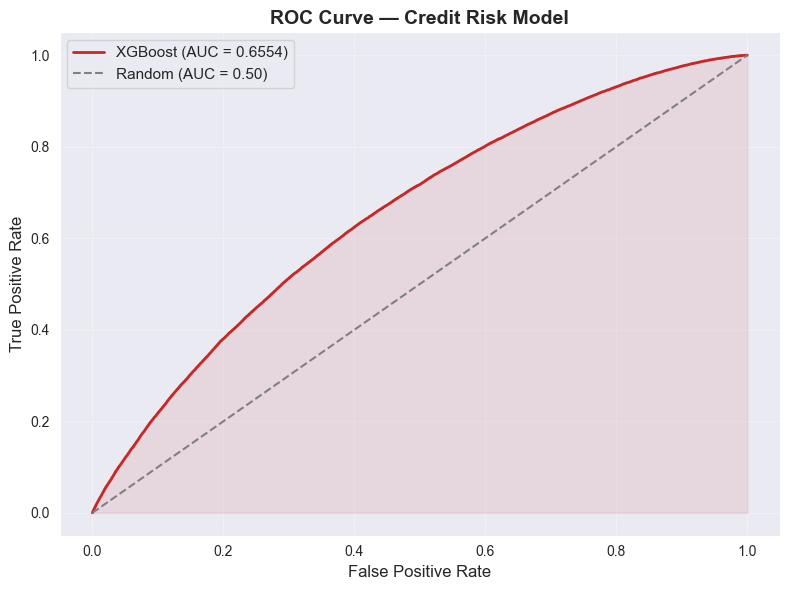

Plot saved to notebooks/roc_curve_xgboost.png


In [11]:
# Cell 9: ROC Curve visualization
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#C62828', linewidth=2, label=f'XGBoost (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#C62828')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Credit Risk Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/roc_curve_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to notebooks/roc_curve_xgboost.png")

Computing SHAP values... (this may take 1-2 minutes)


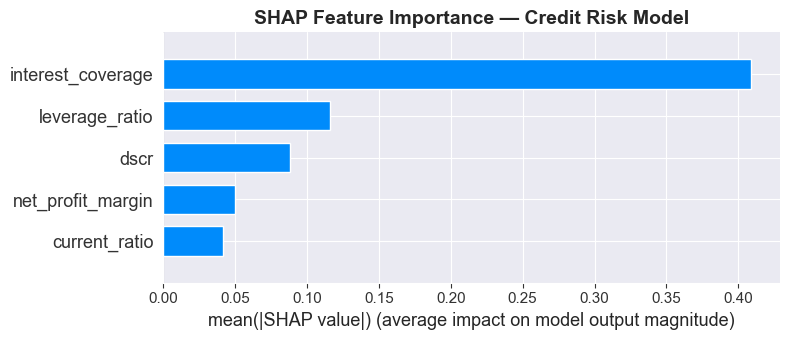

Plot saved to notebooks/shap_feature_importance.png


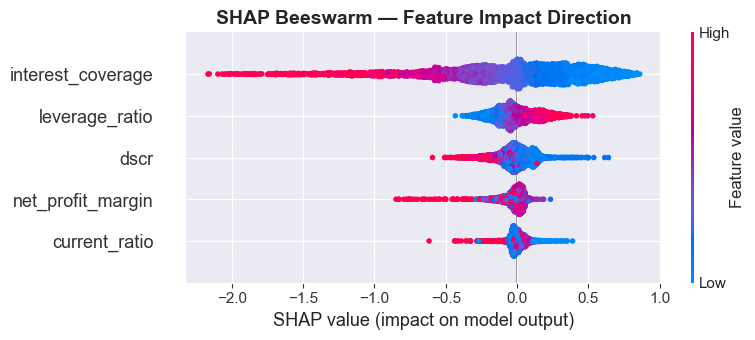

Plot saved to notebooks/shap_beeswarm.png


In [12]:
# Cell 10: SHAP Explainability
print("Computing SHAP values... (this may take 1-2 minutes)")

explainer = shap.TreeExplainer(model)

# Use a sample for SHAP (full dataset takes too long)
X_shap_sample = X_test.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(X_shap_sample)

# SHAP Summary Bar Plot — shows which features matter most
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance — Credit Risk Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to notebooks/shap_feature_importance.png")

# SHAP Beeswarm Plot — shows direction of impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to notebooks/shap_beeswarm.png")

In [13]:
# Cell 11: Define and save risk tier thresholds
# These map the probability score (0.0-1.0) to human-readable risk tiers
# Used by Agent 5 at inference time

tier_thresholds = {
    "low": 0.30,       # 0.00 - 0.30 = Low risk
    "medium": 0.55,    # 0.30 - 0.55 = Medium risk
    "high": 0.75,      # 0.55 - 0.75 = High risk
    "distress": 1.0    # 0.75 - 1.00 = Distress
}

with open('models/tier_thresholds.json', 'w') as f:
    json.dump(tier_thresholds, f, indent=2)

print("Tier thresholds saved to models/tier_thresholds.json")
print(f"\nThreshold mapping:")
prev = 0.0
for tier, upper in tier_thresholds.items():
    print(f"  {prev:.2f} - {upper:.2f} → {tier.upper()}")
    prev = upper

# Show distribution of predictions across tiers
print(f"\nPrediction distribution across tiers (test set):")
for tier, upper in tier_thresholds.items():
    lower = 0.0 if tier == 'low' else list(tier_thresholds.values())[list(tier_thresholds.keys()).index(tier) - 1]
    count = ((y_pred_proba >= lower) & (y_pred_proba < upper)).sum()
    pct = count / len(y_pred_proba) * 100
    print(f"  {tier.upper():10s}: {count:,} loans ({pct:.1f}%)")

Tier thresholds saved to models/tier_thresholds.json

Threshold mapping:
  0.00 - 0.30 → LOW
  0.30 - 0.55 → MEDIUM
  0.55 - 0.75 → HIGH
  0.75 - 1.00 → DISTRESS

Prediction distribution across tiers (test set):
  LOW       : 32,278 loans (12.0%)
  MEDIUM    : 148,501 loans (55.2%)
  HIGH      : 86,872 loans (32.3%)
  DISTRESS  : 1,165 loans (0.4%)


In [14]:
# Cell 12: Save trained model and print final summary

# Save XGBoost model
joblib.dump(model, 'models/credit_risk_model.pkl')
print("Model saved to models/credit_risk_model.pkl")

# Verify all 3 artifacts exist
artifacts = ['models/credit_risk_model.pkl', 'models/medians.json', 'models/tier_thresholds.json']
print(f"\nModel artifacts verification:")
for artifact in artifacts:
    exists = os.path.exists(artifact)
    size_kb = os.path.getsize(artifact) / 1024 if exists else 0
    status = "✓" if exists else "✗"
    print(f"  {status} {artifact} ({size_kb:.1f} KB)")

# Final summary
print(f"\n{'=' * 60}")
print(f"PHASE 3 COMPLETE — MODEL TRAINING SUMMARY")
print(f"{'=' * 60}")
print(f"""
Model: XGBoost Classifier
Features: {FEATURE_COLS}
Training rows: {len(X_train):,}
Test rows: {len(X_test):,}
AUC-ROC: {auc_roc:.4f}
Accuracy: {accuracy:.4f}
F1 Score: {f1:.4f}
Class imbalance handled: scale_pos_weight={scale_pos_weight:.2f}

Artifacts saved:
  1. models/credit_risk_model.pkl (XGBoost model)
  2. models/medians.json (training medians for imputation)
  3. models/tier_thresholds.json (probability → risk tier mapping)

These artifacts are loaded by Agent 5 (Risk Scorer) in the LangGraph pipeline.
""")

Model saved to models/credit_risk_model.pkl

Model artifacts verification:
  ✓ models/credit_risk_model.pkl (1357.5 KB)
  ✓ models/medians.json (0.1 KB)
  ✓ models/tier_thresholds.json (0.1 KB)

PHASE 3 COMPLETE — MODEL TRAINING SUMMARY

Model: XGBoost Classifier
Features: ['dscr', 'leverage_ratio', 'interest_coverage', 'current_ratio', 'net_profit_margin']
Training rows: 1,075,264
Test rows: 268,816
AUC-ROC: 0.6554
Accuracy: 0.5963
F1 Score: 0.3872
Class imbalance handled: scale_pos_weight=4.01

Artifacts saved:
  1. models/credit_risk_model.pkl (XGBoost model)
  2. models/medians.json (training medians for imputation)
  3. models/tier_thresholds.json (probability → risk tier mapping)

These artifacts are loaded by Agent 5 (Risk Scorer) in the LangGraph pipeline.

